In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv("/content/crop-crop.csv")

In [3]:
data.shape

(2200, 8)

In [4]:
data.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


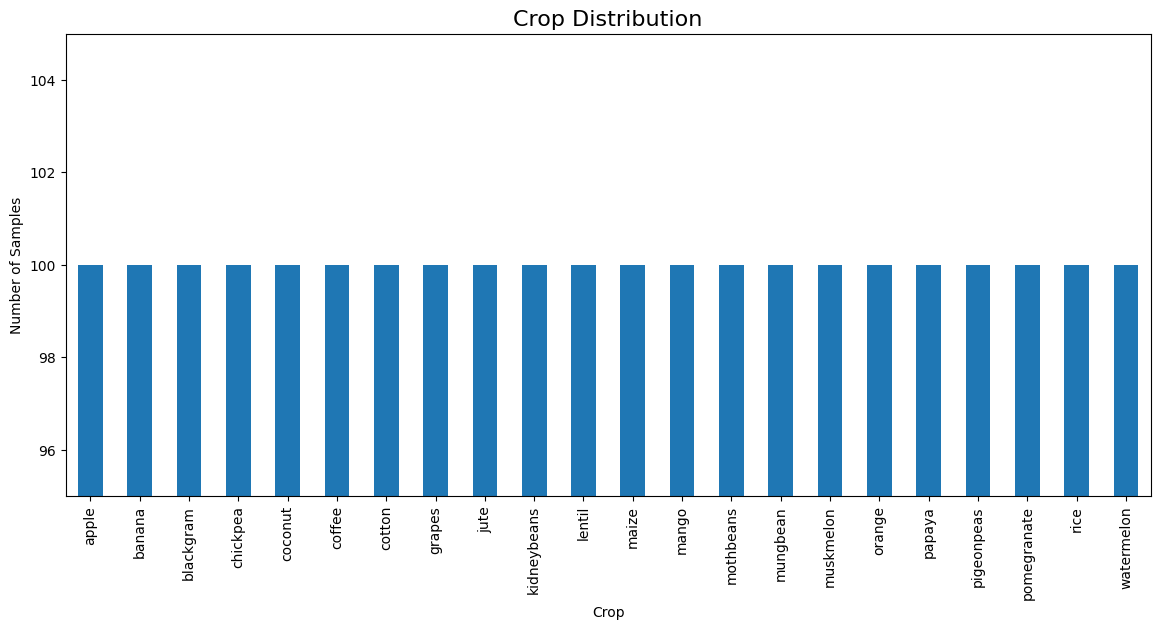

In [5]:
import matplotlib.pyplot as plt

counts = data['label'].value_counts().sort_index()

plt.figure(figsize=(14, 6))
counts.plot(kind='bar')

plt.title("Crop Distribution", fontsize=16)
plt.xlabel("Crop")
plt.ylabel("Number of Samples")

# Zoom in on the range
plt.ylim(95, 105)

plt.show()

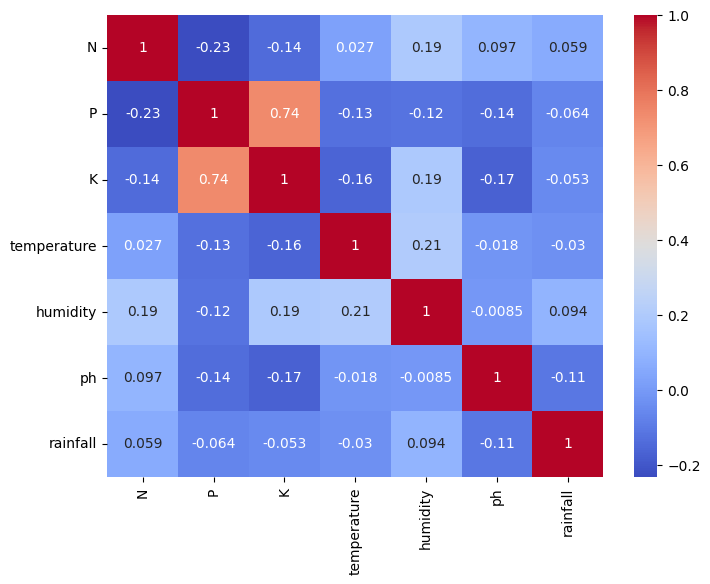

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(data.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")
plt.show()

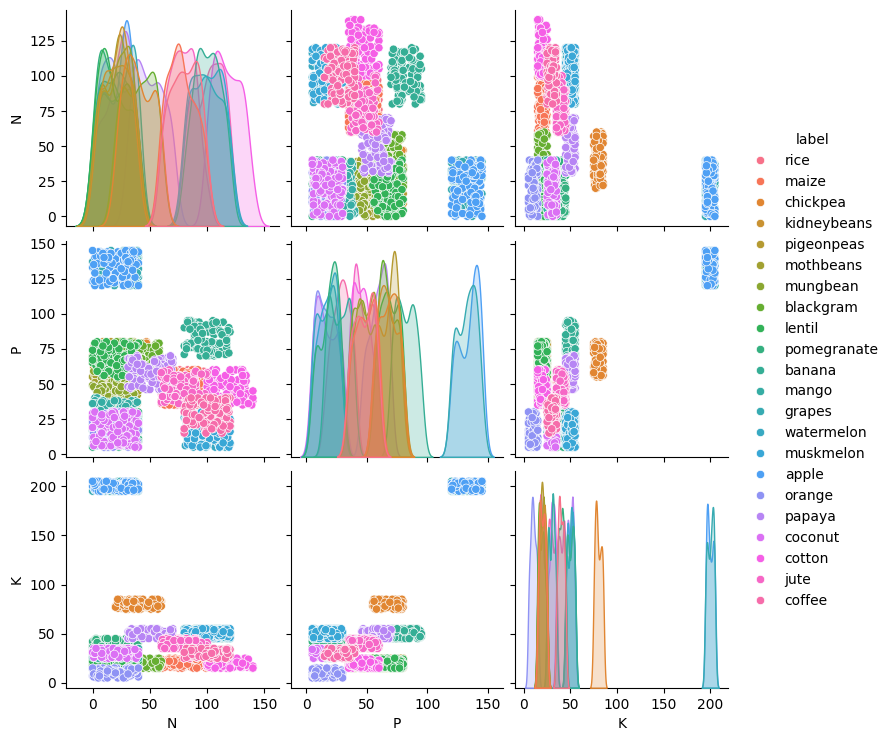

In [7]:
sns.pairplot(
    data,
    hue='label',
    vars=['N','P','K']
)

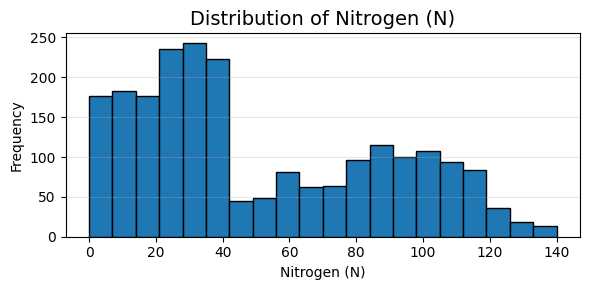

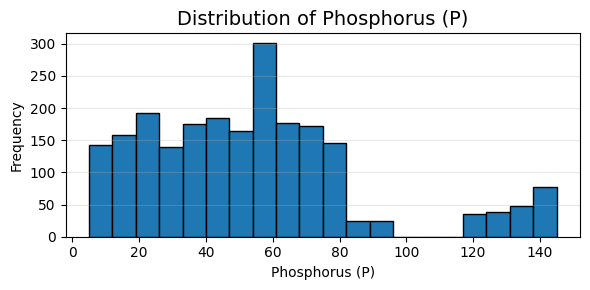

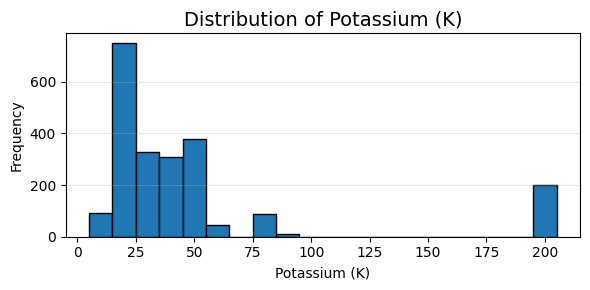

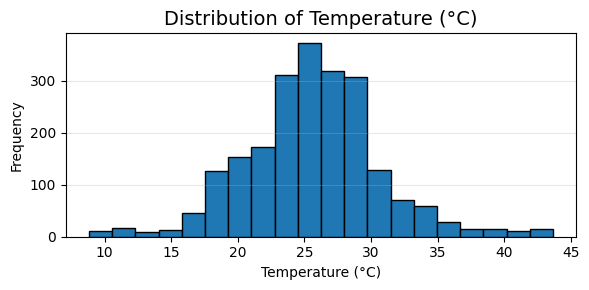

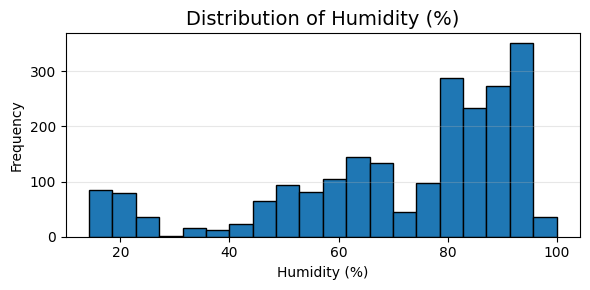

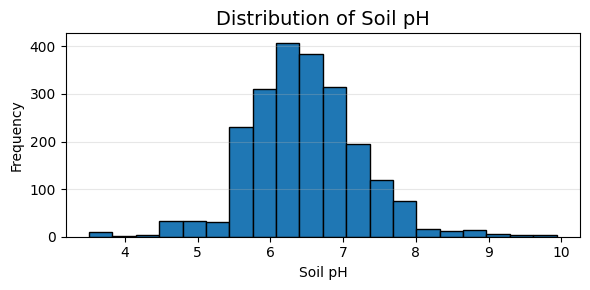

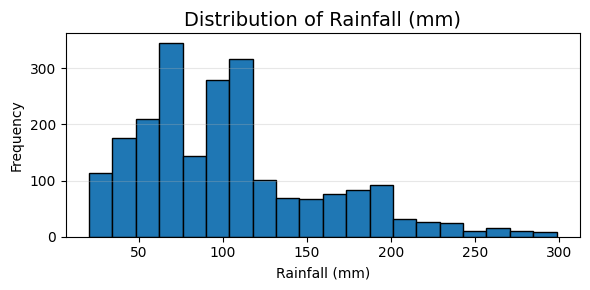

In [8]:
import matplotlib.pyplot as plt

features = [
    ("N", "Nitrogen (N)"),
    ("P", "Phosphorus (P)"),
    ("K", "Potassium (K)"),
    ("temperature", "Temperature (°C)"),
    ("humidity", "Humidity (%)"),
    ("ph", "Soil pH"),
    ("rainfall", "Rainfall (mm)")
]

for column, title in features:
    plt.figure(figsize=(6, 3))

    plt.hist(data[column], bins=20, edgecolor="black")

    plt.title(f"Distribution of {title}", fontsize=14)
    plt.xlabel(title)
    plt.ylabel("Frequency")

    plt.grid(axis="y", alpha=0.3)

    plt.tight_layout()

    plt.savefig(f"{column}_hist.png", dpi=300)

    plt.show()

In [9]:
for col in ['N','P','K','temperature','humidity','ph','rainfall']:
    print(col, data[col].min(), data[col].max())

N 0 140
P 5 145
K 5 205
temperature 8.825674745 43.67549305
humidity 14.25803981 99.98187601
ph 3.504752314 9.93509073
rainfall 20.21126747 298.5601175


<Axes: >

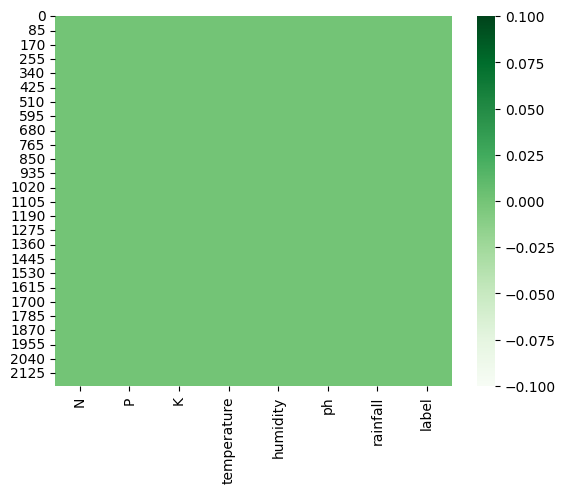

In [12]:
sns.heatmap(data.isnull(), cmap="Greens")

In [13]:
data.isnull().sum()

,0
N,0
P,0
K,0
temperature,0
humidity,0
ph,0
rainfall,0
label,0


In [14]:
data.dtypes

,0
N,int64
P,int64
K,int64
temperature,float64
humidity,float64
ph,float64
rainfall,float64
label,object


In [15]:
non_numeric_cols = data.select_dtypes(exclude="number").columns
print(non_numeric_cols)

Index(['label'], dtype='object')


In [16]:
# label encoader
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
data_final = data
for col in non_numeric_cols:
    data_final[col] = le.fit_transform(data_final[col])

In [17]:
mapping = dict(zip(le.classes_, le.transform(le.classes_)))
for key,value in mapping.items():
    print(key,":",value)

apple : 0
banana : 1
blackgram : 2
chickpea : 3
coconut : 4
coffee : 5
cotton : 6
grapes : 7
jute : 8
kidneybeans : 9
lentil : 10
maize : 11
mango : 12
mothbeans : 13
mungbean : 14
muskmelon : 15
orange : 16
papaya : 17
pigeonpeas : 18
pomegranate : 19
rice : 20
watermelon : 21


In [18]:
import joblib

joblib.dump(le, "label_encoder.pkl")

['label_encoder.pkl']

In [19]:
data_final

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,20
1,85,58,41,21.770462,80.319644,7.038096,226.655537,20
2,60,55,44,23.004459,82.320763,7.840207,263.964248,20
3,74,35,40,26.491096,80.158363,6.980401,242.864034,20
4,78,42,42,20.130175,81.604873,7.628473,262.717340,20
...,...,...,...,...,...,...,...,...
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,5
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,5
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,5
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,5


In [20]:
# x = data_finalist.drop(columns={"Osteoporosis"},axis = 1)
x = data_final.drop(columns={"label"},axis = 1)
y = data_final["label"]

In [21]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=0)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(1760, 7)
(440, 7)
(1760,)
(440,)


# **K-Nearest Neighbours**

In [22]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=10)
knn.fit(x_train, y_train)

KNeighborsClassifier(n_neighbors=10)

In [23]:
y_pred = knn.predict(x_test)


accuracy score:  0.9795454545454545 



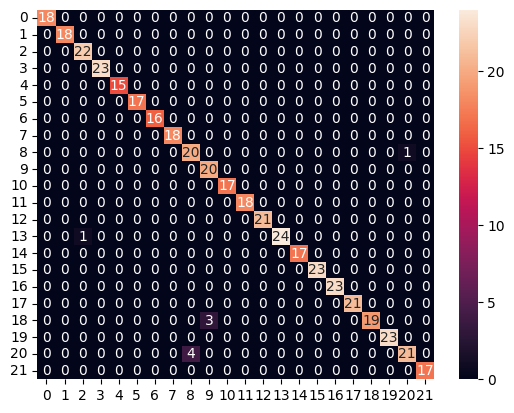

In [24]:
from sklearn.metrics import confusion_matrix,accuracy_score,classification_report
conf_matrix_knn = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix_knn,annot=True,fmt='d')
print("\naccuracy score: " , accuracy_score(y_test, y_pred),"\n")

In [25]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(knn, x, y, cv=5)

print("Scores:",scores)
print("Mean Accuracy: ",scores.mean())

Scores: [0.96590909 0.975      0.97954545 0.96590909 0.97045455]
Mean Accuracy:  0.9713636363636363


In [26]:
crknn = classification_report(y_test, y_pred)
print(crknn)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       1.00      1.00      1.00        18
           2       0.96      1.00      0.98        22
           3       1.00      1.00      1.00        23
           4       1.00      1.00      1.00        15
           5       1.00      1.00      1.00        17
           6       1.00      1.00      1.00        16
           7       1.00      1.00      1.00        18
           8       0.83      0.95      0.89        21
           9       0.87      1.00      0.93        20
          10       1.00      1.00      1.00        17
          11       1.00      1.00      1.00        18
          12       1.00      1.00      1.00        21
          13       1.00      0.96      0.98        25
          14       1.00      1.00      1.00        17
          15       1.00      1.00      1.00        23
          16       1.00      1.00      1.00        23
          17       1.00    

## 1. Precision

**Definition:** Out of all samples predicted as a class, how many were actually that class?

$$
\text{Precision} = \frac{TP}{TP + FP}
$$


**Interpretation:** High precision means that when the model predicts a class, it is usually correct.

---

## 2. Recall

**Definition:** Out of all actual samples of a class, how many did the model correctly identify?

$$
\text{Recall} = \frac{TP}{TP + FN}
$$

**Interpretation:** High recall means the model rarely misses samples of that class.

---

## 3. F1-Score

**Definition:** The harmonic mean of precision and recall.

$$
F1 = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}
$$

**Interpretation:** A higher F1-score indicates a better balance between precision and recall.

---

## 4. Support

**Definition:** The number of actual samples belonging to a class in the test dataset.

$$
\text{Support} = \text{Number of actual samples of the class}
$$

---

## 5. Accuracy

**Definition:** The percentage of predictions that are correct.

$$
\text{Accuracy} = \frac{\text{Correct Predictions}}{\text{Total Predictions}}
$$

**Interpretation:** Overall percentage of correctly classified samples.

---

## 6. Macro Average

$$
\text{Macro Average} =
\frac{M_1 + M_2 + \cdots + M_n}{n}
$$

Where:
- $M_i$ = Metric (Precision, Recall, or F1) for class $i$
- $n$ = Number of classes

**Interpretation:** Every class contributes equally, regardless of how many samples it has.

---

## 7. Weighted Average

$$
\text{Weighted Average} =
\frac{M_1S_1 + M_2S_2 + \cdots + M_nS_n}
{S_1 + S_2 + \cdots + S_n}
$$

Where:
- $M_i$ = Metric for class $i$
- $S_i$ = Support for class $i$

**Interpretation:** Classes with more samples have a greater influence on the final score.

# **Logistic Regression**

In [33]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_scaled = scaler.fit_transform(x)
x_train_scaled = scaler.transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [34]:
from sklearn.linear_model import LogisticRegression
logm = LogisticRegression(max_iter=100)
logm.fit(x_train_scaled,y_train)

LogisticRegression()

In [35]:
log_pred = logm.predict(x_test_scaled)

<Axes: >

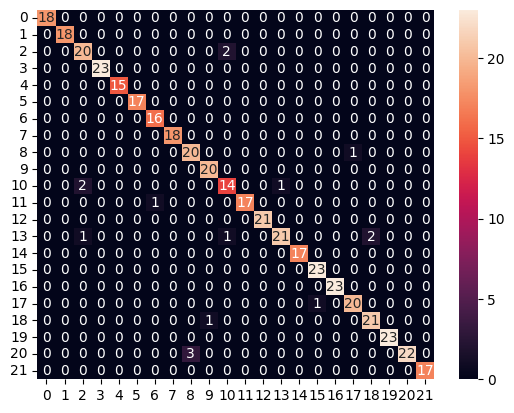

In [36]:
conf_matrix_logm = confusion_matrix(y_test,log_pred)
sns.heatmap(conf_matrix_logm,annot = True,fmt='d')

In [37]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(logm, x_scaled, y, cv=5)

print("Scores:",scores)
print("Mean Accuracy: ",scores.mean())

Scores: [0.97272727 0.95454545 0.97727273 0.96818182 0.98409091]
Mean Accuracy:  0.9713636363636363


In [38]:
crlog = classification_report(y_test,log_pred)
print(crlog)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       1.00      1.00      1.00        18
           2       0.87      0.91      0.89        22
           3       1.00      1.00      1.00        23
           4       1.00      1.00      1.00        15
           5       1.00      1.00      1.00        17
           6       0.94      1.00      0.97        16
           7       1.00      1.00      1.00        18
           8       0.87      0.95      0.91        21
           9       0.95      1.00      0.98        20
          10       0.82      0.82      0.82        17
          11       1.00      0.94      0.97        18
          12       1.00      1.00      1.00        21
          13       0.95      0.84      0.89        25
          14       1.00      1.00      1.00        17
          15       0.96      1.00      0.98        23
          16       1.00      1.00      1.00        23
          17       0.95    

#**Support Vector Machine**


In [39]:
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score

linear = SVC(kernel="linear")
rbf = SVC(kernel="rbf")

linear_score = cross_val_score(
    linear,
    x_scaled,
    y,
    cv=5
).mean()

rbf_score = cross_val_score(
    rbf,
    x_scaled,
    y,
    cv=5
).mean()

In [40]:
print("Linear:", linear_score)
print("RBF:", rbf_score)

Linear: 0.9822727272727272
RBF: 0.9822727272727272


In [41]:
linear.fit(x_train_scaled,y_train)
svm_pred = linear.predict(x_test_scaled)

<Axes: >

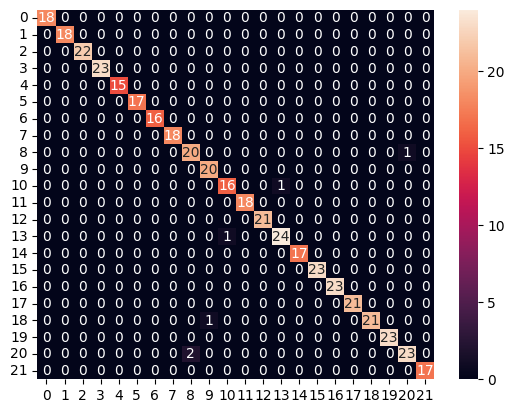

In [42]:
conf_matrix_svm= confusion_matrix(y_test,svm_pred)
sns.heatmap(conf_matrix_svm,annot = True,fmt='d')

In [43]:
crsvm = classification_report(y_test,svm_pred)
print(crsvm)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       1.00      1.00      1.00        18
           2       1.00      1.00      1.00        22
           3       1.00      1.00      1.00        23
           4       1.00      1.00      1.00        15
           5       1.00      1.00      1.00        17
           6       1.00      1.00      1.00        16
           7       1.00      1.00      1.00        18
           8       0.91      0.95      0.93        21
           9       0.95      1.00      0.98        20
          10       0.94      0.94      0.94        17
          11       1.00      1.00      1.00        18
          12       1.00      1.00      1.00        21
          13       0.96      0.96      0.96        25
          14       1.00      1.00      1.00        17
          15       1.00      1.00      1.00        23
          16       1.00      1.00      1.00        23
          17       1.00    

# Gaussian Naive Bayes

Gaussian Naive Bayes is used for **continuous numerical features**. It assumes that every feature follows a **Gaussian (Normal) distribution** within each class.

---

## Bayes' Theorem

$$
P(C|X)=\frac{P(X|C)\,P(C)}{P(X)}
$$

where

- $P(C|X)$ = Posterior Probability
- $P(X|C)$ = Likelihood
- $P(C)$ = Prior Probability
- $P(X)$ = Evidence

Since $P(X)$ is the same for all classes,

$$
P(C|X)\propto P(X|C)\times P(C)
$$

---

## Naive Independence Assumption

Assuming all features are conditionally independent,

$$
P(X|C)=
\prod_{i=1}^{n}P(x_i|C)
$$

where

- $x_i$ = ith feature
- $n$ = Number of features

---

## Gaussian Probability Density Function

For every feature,

$$
P(x_i|C)=
\frac{1}{\sqrt{2\pi\sigma_C^2}}
\exp\left(
-\frac{(x_i-\mu_C)^2}
{2\sigma_C^2}
\right)
$$

where

- $x_i$ = Feature value
- $\mu_C$ = Mean of the feature for class $C$
- $\sigma_C$ = Standard deviation of the feature for class $C$

---

## Final Gaussian Naive Bayes Formula

$$
P(C|X)\propto
P(C)
\prod_{i=1}^{n}
\frac{1}{\sqrt{2\pi\sigma_C^2}}
\exp\left(
-\frac{(x_i-\mu_C)^2}
{2\sigma_C^2}
\right)
$$

The predicted class is

$$
\hat{y}
=
\arg\max_C
P(C|X)
$$

That is, choose the class with the highest posterior probability.

---

## Training Phase

For every class and every feature, Gaussian Naive Bayes learns:

- Mean ($\mu$)
- Standard Deviation ($\sigma$)
- Prior Probability ($P(C)$)

No feature scaling is required.

---

## Prediction Phase

For a new sample:

1. Compute the Gaussian PDF for every feature.
2. Multiply all feature likelihoods together.
3. Multiply by the prior probability.
4. Predict the class with the highest posterior probability.

In [44]:
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb.fit(x_train,y_train)

GaussianNB()

In [45]:
nb_pred = nb.predict(x_test)

<Axes: >

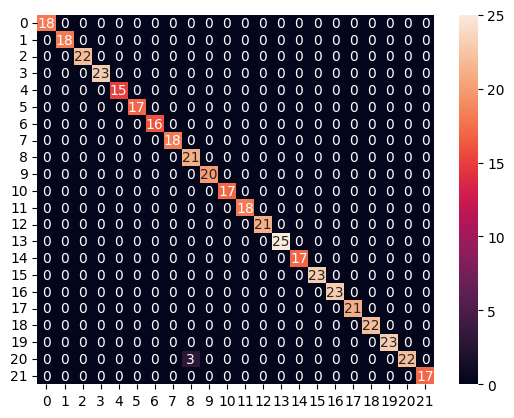

In [46]:
conf_matrix_nb = confusion_matrix(y_test,nb_pred)
sns.heatmap(conf_matrix_nb,annot=True,fmt='d')

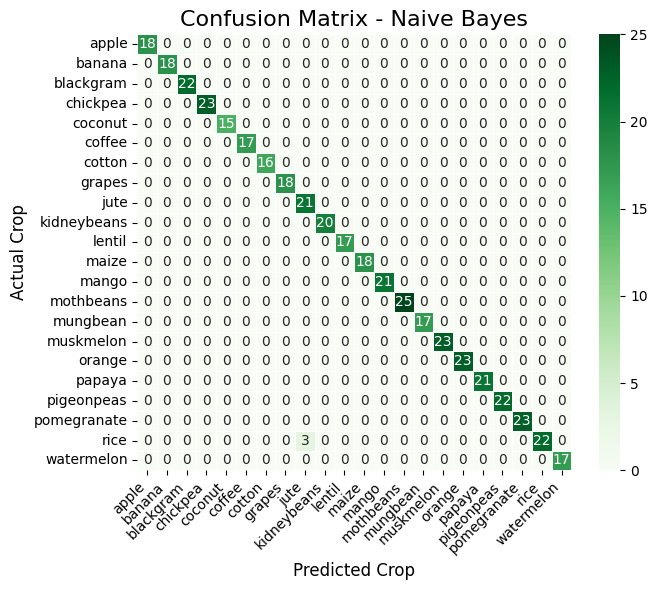

In [141]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Create confusion matrix
cm = confusion_matrix(y_test, nb_pred)

# Get crop names
labels = le.classes_

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=labels,
    yticklabels=labels,
    linewidths=0.5
)

plt.xlabel("Predicted Crop", fontsize=12)
plt.ylabel("Actual Crop", fontsize=12)
plt.title("Confusion Matrix - Naive Bayes", fontsize=16)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [48]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(nb, x, y, cv=5)

print("Scores:",scores)
print("Mean Accuracy: ",scores.mean())

Scores: [0.99772727 0.99545455 0.99545455 0.99545455 0.99090909]
Mean Accuracy:  0.9950000000000001


In [49]:
crnb = classification_report(y_test,nb_pred)
print(crnb)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       1.00      1.00      1.00        18
           2       1.00      1.00      1.00        22
           3       1.00      1.00      1.00        23
           4       1.00      1.00      1.00        15
           5       1.00      1.00      1.00        17
           6       1.00      1.00      1.00        16
           7       1.00      1.00      1.00        18
           8       0.88      1.00      0.93        21
           9       1.00      1.00      1.00        20
          10       1.00      1.00      1.00        17
          11       1.00      1.00      1.00        18
          12       1.00      1.00      1.00        21
          13       1.00      1.00      1.00        25
          14       1.00      1.00      1.00        17
          15       1.00      1.00      1.00        23
          16       1.00      1.00      1.00        23
          17       1.00    

# **Decision Tree**

In [71]:
from sklearn.tree import DecisionTreeClassifier
dst = DecisionTreeClassifier()
dst.fit(x_train,y_train)

DecisionTreeClassifier()

In [72]:
dst_pred = dst.predict(x_test)

<Axes: >

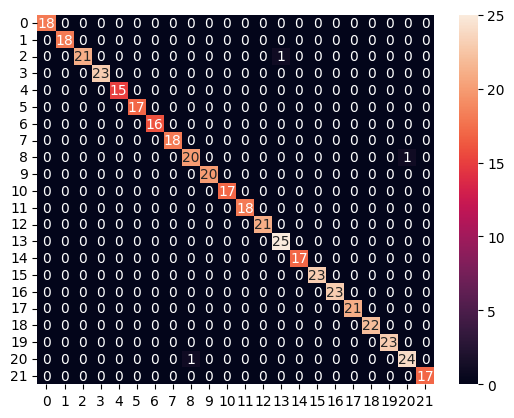

In [73]:
conf_matrix_dst = confusion_matrix(y_test,dst_pred)
sns.heatmap(conf_matrix_dst,annot=True,fmt='d')

In [74]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(dst, x, y, cv=5)

print("Scores:",scores)
print("Mean Accuracy: ",scores.mean())

Scores: [0.99090909 0.98409091 0.99090909 0.99090909 0.98181818]
Mean Accuracy:  0.9877272727272727


In [75]:
crdst = classification_report(y_test,dst_pred)
print(crdst)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       1.00      1.00      1.00        18
           2       1.00      0.95      0.98        22
           3       1.00      1.00      1.00        23
           4       1.00      1.00      1.00        15
           5       1.00      1.00      1.00        17
           6       1.00      1.00      1.00        16
           7       1.00      1.00      1.00        18
           8       0.95      0.95      0.95        21
           9       1.00      1.00      1.00        20
          10       1.00      1.00      1.00        17
          11       1.00      1.00      1.00        18
          12       1.00      1.00      1.00        21
          13       0.96      1.00      0.98        25
          14       1.00      1.00      1.00        17
          15       1.00      1.00      1.00        23
          16       1.00      1.00      1.00        23
          17       1.00    

# **Random Forest**

In [118]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators = 10)
rf.fit(x_train,y_train)

RandomForestClassifier(n_estimators=10)

In [119]:
rf_pred = rf.predict(x_test)

<Axes: >

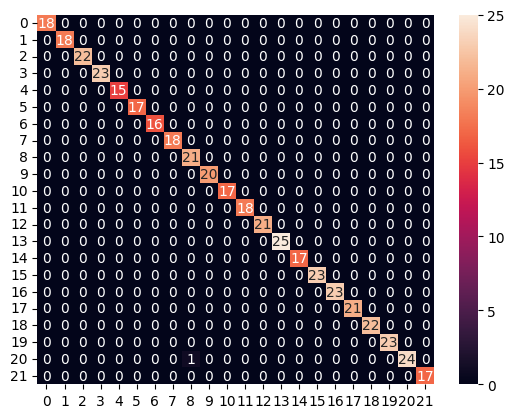

In [120]:
conf_matrix_rf = confusion_matrix(y_test,rf_pred)
sns.heatmap(conf_matrix_rf,annot=True,fmt='d')

In [121]:
crrf = classification_report(y_test,rf_pred)
print(crrf)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       1.00      1.00      1.00        18
           2       1.00      1.00      1.00        22
           3       1.00      1.00      1.00        23
           4       1.00      1.00      1.00        15
           5       1.00      1.00      1.00        17
           6       1.00      1.00      1.00        16
           7       1.00      1.00      1.00        18
           8       0.95      1.00      0.98        21
           9       1.00      1.00      1.00        20
          10       1.00      1.00      1.00        17
          11       1.00      1.00      1.00        18
          12       1.00      1.00      1.00        21
          13       1.00      1.00      1.00        25
          14       1.00      1.00      1.00        17
          15       1.00      1.00      1.00        23
          16       1.00      1.00      1.00        23
          17       1.00    

In [122]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf, x, y, cv=5)

print("Scores:",scores)
print("Mean Accuracy: ",scores.mean())

Scores: [0.99545455 0.99772727 0.99318182 0.99318182 0.98636364]
Mean Accuracy:  0.9931818181818182


In [124]:
import joblib

joblib.dump(nb, "crop_recommendation_nb.pkl")

['crop_recommendation_nb.pkl']

# **Neural Network**

In [125]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [135]:
model = Sequential([
    Dense(64, activation='relu', input_shape=(x_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(len(le.classes_), activation='softmax')  # output layer for classification
])

# 7. Compile
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [136]:
history = model.fit(x_train_scaled, y_train, epochs=100, batch_size=16, validation_split=0.2, verbose=1)

Epoch 1/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.2578 - loss: 2.6518 - val_accuracy: 0.4375 - val_loss: 2.1952
Epoch 2/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5930 - loss: 1.6555 - val_accuracy: 0.7386 - val_loss: 1.2261
Epoch 3/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8317 - loss: 0.8809 - val_accuracy: 0.8466 - val_loss: 0.6889
Epoch 4/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9020 - loss: 0.5297 - val_accuracy: 0.8920 - val_loss: 0.4911
Epoch 5/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9197 - loss: 0.3758 - val_accuracy: 0.9148 - val_loss: 0.3810
Epoch 6/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9276 - loss: 0.2942 - val_accuracy: 0.9290 - val_loss: 0.3075
Epoch 7/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9396 - loss: 0.2399 - val_accuracy: 0.9261 - val_loss: 0.2632
Epoch 8/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9538 - loss: 0.1991 - val_accuracy: 0.9176 - v

In [137]:
loss, accuracy = model.evaluate(x_test_scaled, y_test)
print(f"Test Accuracy: {accuracy:.2f}")

# 10. Predict sample
sample = x_test_scaled[420].reshape(1, -1)
pred = model.predict(sample)
print("Predicted Crop:", le.inverse_transform([pred.argmax()])[0])


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9864 - loss: 0.0547  
Test Accuracy: 0.99
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
Predicted Crop: watermelon


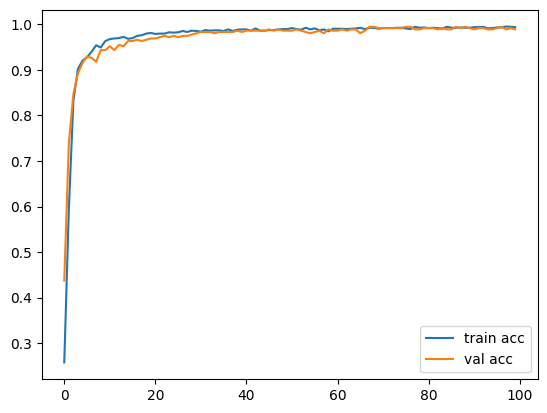

In [138]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.legend()
plt.show()

In [139]:
models = ['KNN','LR','LSVM','RF','DST','NB','ANN']
accuracy = [0.97136,0.97136,0.98227,0.99318,0.98772,0.995, 0.9864]

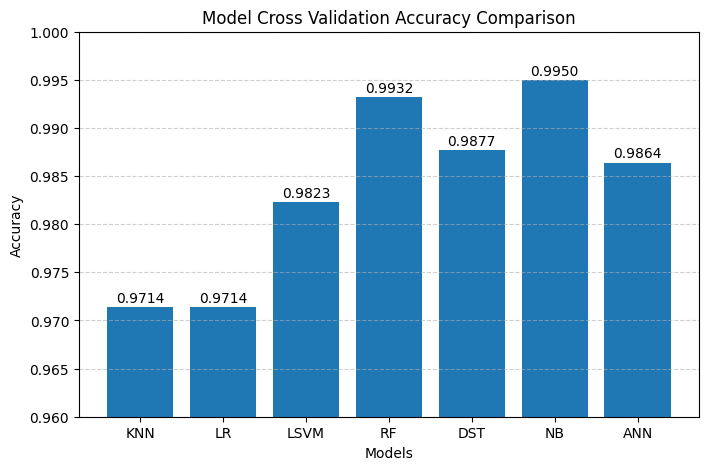

In [140]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(models, accuracy)

# Zoom the y-axis
plt.ylim(0.96, 1.00)

plt.ylabel("Accuracy")
plt.xlabel("Models")
plt.title("Model Cross Validation Accuracy Comparison")

# Show exact values on top of bars
for i, v in enumerate(accuracy):
    plt.text(i, v + 0.0005, f"{v:.4f}", ha='center', fontsize=10)

plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()